# 1. Introdution

## Credit Card Fraud Detection — Exploratory Data Analysis

This notebook performs exploratory data analysis (EDA) on a credit card transaction dataset to understand patterns associated with fraudulent transactions.

The goal of this analysis is to:

- Understand the overall fraud rate in the dataset
- Explore transaction behavior differences between fraud and normal transactions
- Identify potential risk signals for feature engineering
- Provide insights for building a fraud risk scoring model

# 2. Load Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("./CreditCardFraud_updated.csv")

df.head()

,Unnamed: 0,accountNumber,customerId,creditLimit,availableMoney,transactionDateTime,transactionAmount,merchantName,acqCountry,merchantCountryCode,...,echoBuffer,currentBalance,merchantCity,merchantState,merchantZip,cardPresent,posOnPremises,recurringAuthInd,expirationDateKeyInMatch,isFraud
0,0,737265056,737265056,5000.0,5000.0,2016-08-13T14:27:32,98.55,Uber,US,US,...,NaN,0.0,NaN,NaN,NaN,False,NaN,NaN,False,False
1,1,737265056,737265056,5000.0,5000.0,2016-10-11T05:05:54,74.51,AMC #191138,US,US,...,NaN,0.0,NaN,NaN,NaN,True,NaN,NaN,False,False
2,2,737265056,737265056,5000.0,5000.0,2016-11-08T09:18:39,7.47,Play Store,US,US,...,NaN,0.0,NaN,NaN,NaN,False,NaN,NaN,False,False
3,3,737265056,737265056,5000.0,5000.0,2016-12-10T02:14:50,7.47,Play Store,US,US,...,NaN,0.0,NaN,NaN,NaN,False,NaN,NaN,False,False
4,4,830329091,830329091,5000.0,5000.0,2016-03-24T21:04:46,71.18,Tim Hortons #947751,US,US,...,NaN,0.0,NaN,NaN,NaN,True,NaN,NaN,False,False


# 3. Data Overview

In [3]:
df.shape

(786363, 30)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 786363 entries, 0 to 786362
Data columns (total 30 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Unnamed: 0                786363 non-null  int64  
 1   accountNumber             786363 non-null  int64  
 2   customerId                786363 non-null  int64  
 3   creditLimit               786363 non-null  float64
 4   availableMoney            786363 non-null  float64
 5   transactionDateTime       786363 non-null  object 
 6   transactionAmount         786363 non-null  float64
 7   merchantName              786363 non-null  object 
 8   acqCountry                781801 non-null  object 
 9   merchantCountryCode       785639 non-null  object 
 10  posEntryMode              782309 non-null  float64
 11  posConditionCode          785954 non-null  float64
 12  merchantCategoryCode      786363 non-null  object 
 13  currentExpDate            786363 non-null  o

In [5]:
df.describe()

,Unnamed: 0,accountNumber,customerId,creditLimit,availableMoney,transactionAmount,posEntryMode,posConditionCode,cardCVV,enteredCVV,cardLast4Digits,echoBuffer,currentBalance,merchantCity,merchantState,merchantZip,posOnPremises,recurringAuthInd
count,786363.000000,7.863630e+05,7.863630e+05,786363.000000,786363.000000,7.863630e+05,782309.000000,785954.000000,786363.000000,786363.000000,786363.000000,0.0,786363.000000,0.0,0.0,0.0,0.0,0.0
mean,393181.000000,5.372326e+08,5.372326e+08,10759.464459,6250.725369,5.617512e+02,9.049943,3.271980,544.467338,544.183857,4757.417799,NaN,4508.739089,NaN,NaN,NaN,NaN,NaN
std,227003.589203,2.554211e+08,2.554211e+08,11636.174890,8880.783989,1.124137e+04,16.774130,9.809023,261.524220,261.551254,2996.583810,NaN,6457.442068,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000881e+08,1.000881e+08,250.000000,-1005.630000,0.000000e+00,2.000000,1.000000,100.000000,0.000000,0.000000,NaN,0.000000,NaN,NaN,NaN,NaN,NaN
25%,196590.500000,3.301333e+08,3.301333e+08,5000.000000,1077.420000,3.378000e+01,2.000000,1.000000,310.000000,310.000000,2178.000000,NaN,689.910000,NaN,NaN,NaN,NaN,NaN
50%,393181.000000,5.074561e+08,5.074561e+08,7500.000000,3184.860000,8.836000e+01,5.000000,1.000000,535.000000,535.000000,4733.000000,NaN,2451.760000,NaN,NaN,NaN,NaN,NaN
75%,589771.500000,7.676200e+08,7.676200e+08,15000.000000,7500.000000,1.928200e+02,9.000000,1.000000,785.000000,785.000000,7338.000000,NaN,5291.095000,NaN,NaN,NaN,NaN,NaN
max,786362.000000,9.993896e+08,9.993896e+08,50000.000000,50000.000000,1.106070e+06,90.000000,99.000000,998.000000,998.000000,9998.000000,NaN,47498.810000,NaN,NaN,NaN,NaN,NaN


The dataset contains transaction-level records including:

- transaction amount
- merchant information
- card information
- transaction timestamps
- fraud label (`isFraud`)

# 4. Fraud Base Rate

In [ ]:
fraud_rate = df['isFraud'].mean()
fraud_rate

isFraud
False     549.497967
True     1325.490063
Name: transactionAmount, dtype: float64

In [6]:
df['isFraud'].value_counts()

isFraud
False    773946
True      12417
Name: count, dtype: int64

Fraud detection is a highly imbalanced classification problem.

The fraud rate in this dataset is approximately **X%**, which means that most transactions are legitimate.

# 5. Transaction Amount Analysis

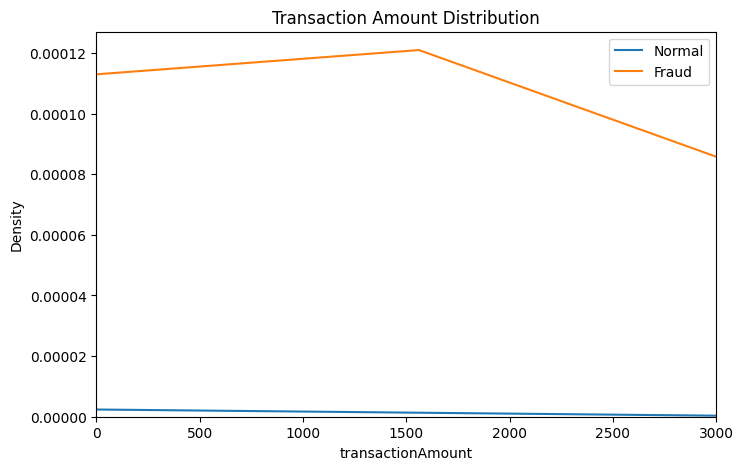

In [ ]:
# Distribution of Transaction Amount
plt.figure(figsize=(8,5))

sns.kdeplot(
    df[df.isFraud==0]['transactionAmount'],
    label="Normal"
)

sns.kdeplot(
    df[df.isFraud==1]['transactionAmount'],
    label="Fraud"
)

plt.xlim(0,3000)
plt.legend()
plt.title("Transaction Amount Distribution")
plt.show()

In [ ]:
# Average Transaction Amount
df.groupby("isFraud")["transactionAmount"].mean()

isFraud
False     549.497967
True     1325.490063
Name: transactionAmount, dtype: float64

Fraudulent transactions tend to have higher transaction amounts on average.

Because transaction amounts are highly skewed, a log transformation may help stabilize variance for modeling.

# 6. Authentication Signals

In [12]:
# CVV Match Feature
df["cvv_match"] = (df["cardCVV"] == df["enteredCVV"]).astype(int)

cvv_rate = df.groupby("cvv_match")["isFraud"].mean()
cvv_rate

cvv_match
0    0.028938
1    0.015672
Name: isFraud, dtype: float64

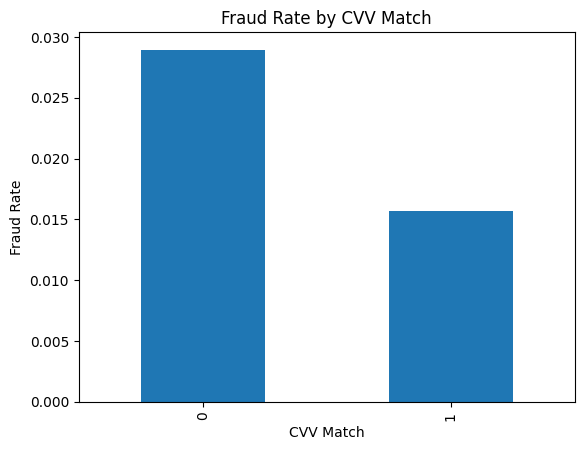

In [ ]:
# Visuaization
cvv_rate.plot(kind="bar")

plt.xlabel("CVV Match")
plt.ylabel("Fraud Rate")
plt.title("Fraud Rate by CVV Match")

plt.show()

In [ ]:
# 7. Card Usage Behavior

In [14]:
# Card Usage Frequency
card4_freq = df["cardLast4Digits"].value_counts()

df["card4_freq"] = df["cardLast4Digits"].map(card4_freq)

In [16]:
# Bin analysis
df["card4_bin"] = pd.qcut(df["card4_freq"], q=5)

df.groupby("card4_bin")["isFraud"].mean()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_26808\3434745421.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("card4_bin")["isFraud"].mean()


card4_bin
(0.999, 125.0]       0.012701
(125.0, 318.0]       0.015135
(318.0, 704.0]       0.015207
(704.0, 2263.0]      0.017675
(2263.0, 32946.0]    0.018247
Name: isFraud, dtype: float64

Cards with unusually high transaction frequency may indicate suspicious activity.

This feature may help identify abnormal card usage patterns.

# 8. Merchant Risk Patterns

In [17]:
merchant_rate = df.groupby("merchantName")["isFraud"].mean()

merchant_rate.sort_values(ascending=False).head(10)

merchantName
In-N-Out #949129     0.112360
American Airlines    0.093979
In-N-Out #863086     0.093750
In-N-Out #463194     0.083333
In-N-Out #422833     0.081818
In-N-Out #567597     0.078652
Walgreens #475572    0.071429
In-N-Out #17755      0.068627
Fresh Flowers        0.066355
In-N-Out #899468     0.066038
Name: isFraud, dtype: float64

Some merchants show higher fraud concentration.

However, merchant-level fraud rates should be used carefully to avoid data leakage during model training.

# 9. Transaction Type Risk

In [18]:
type_rate = df.groupby("transactionType")["isFraud"].mean().sort_values()

type_rate

transactionType
ADDRESS_VERIFICATION    0.005751
PURCHASE                0.016036
REVERSAL                0.016599
Name: isFraud, dtype: float64

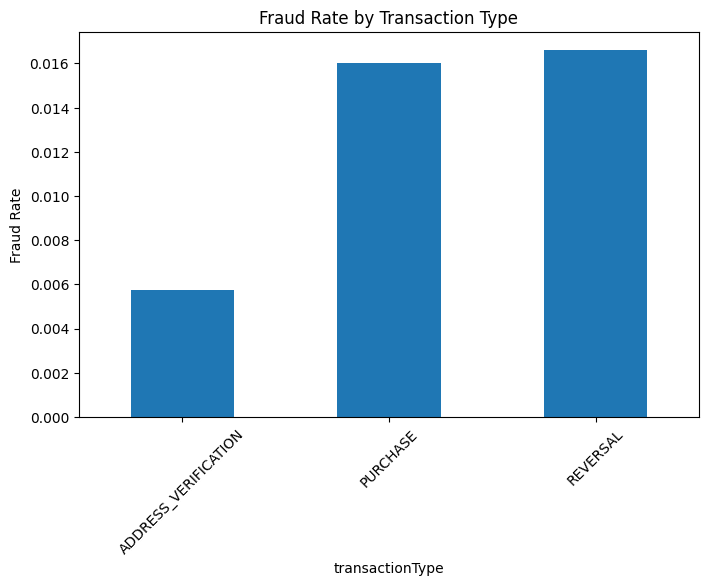

In [25]:
# Visualization
plt.figure(figsize=(8,5))
type_rate.plot(kind="bar")

plt.ylabel("Fraud Rate")
plt.title("Fraud Rate by Transaction Type")
plt.xticks(rotation=45) 

plt.show()

Transactions where the entered CVV does not match the stored CVV show significantly higher fraud rates.

This suggests that CVV mismatch can be a useful fraud detection feature.

# 7. Card Usage Behavior

In [26]:
# Card Usage Frequency
card4_freq = df["cardLast4Digits"].value_counts()

df["card4_freq"] = df["cardLast4Digits"].map(card4_freq)

In [27]:
# Bin analysis
df["card4_bin"] = pd.qcut(df["card4_freq"], q=5)

df.groupby("card4_bin")["isFraud"].mean()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_26808\3434745421.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("card4_bin")["isFraud"].mean()


card4_bin
(0.999, 125.0]       0.012701
(125.0, 318.0]       0.015135
(318.0, 704.0]       0.015207
(704.0, 2263.0]      0.017675
(2263.0, 32946.0]    0.018247
Name: isFraud, dtype: float64

Cards with unusually high transaction frequency may indicate suspicious activity.

This feature may help identify abnormal card usage patterns.

# 8.Merchant Risk Patterns

In [28]:
merchant_rate = df.groupby("merchantName")["isFraud"].mean()

merchant_rate.sort_values(ascending=False).head(10)

merchantName
In-N-Out #949129     0.112360
American Airlines    0.093979
In-N-Out #863086     0.093750
In-N-Out #463194     0.083333
In-N-Out #422833     0.081818
In-N-Out #567597     0.078652
Walgreens #475572    0.071429
In-N-Out #17755      0.068627
Fresh Flowers        0.066355
In-N-Out #899468     0.066038
Name: isFraud, dtype: float64

Some merchants show higher fraud concentration.

However, merchant-level fraud rates should be used carefully to avoid data leakage during model training.

# 9.Transaction Type Risk

In [29]:
type_rate = df.groupby("transactionType")["isFraud"].mean().sort_values()

type_rate

transactionType
ADDRESS_VERIFICATION    0.005751
PURCHASE                0.016036
REVERSAL                0.016599
Name: isFraud, dtype: float64

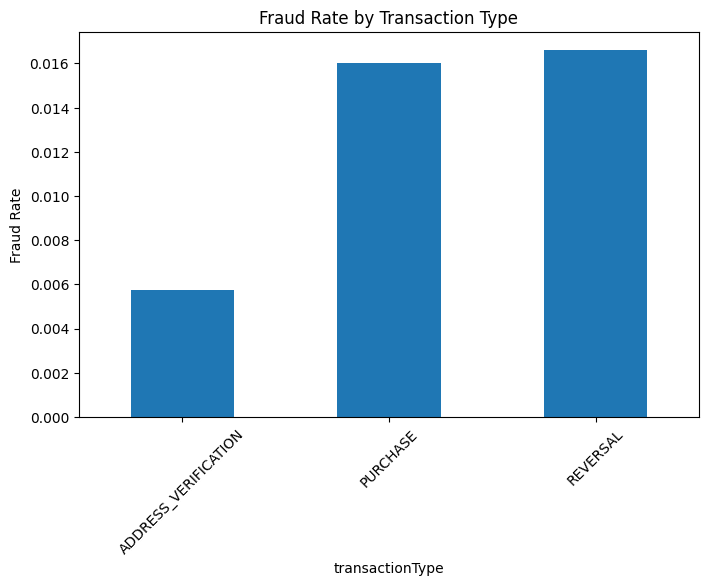

In [32]:
# Visualization
plt.figure(figsize = (8,5))
type_rate.plot(kind="bar")

plt.ylabel("Fraud Rate")
plt.title("Fraud Rate by Transaction Type")
plt.xticks(rotation = 45)

plt.show()

# 10. Key Insights from EDA

Key findings from exploratory data analysis:

1. Fraud transactions tend to have higher transaction amounts.
2. CVV mismatches are strongly associated with fraudulent activity.
3. Certain transaction behaviors such as unusually high card usage frequency may indicate suspicious activity.
4. Merchant and transaction type patterns suggest that some categories have higher fraud exposure.

These insights guide feature engineering for the fraud risk model.

# 11.Next Step

Based on these observations, the next step is to build a fraud risk scoring model.

Key engineered features include:

- CVV match indicator
- transaction amount log transformation
- card usage frequency
- transaction timing features
- balance utilization ratios